In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report

sns.set_theme(style="whitegrid")

In [24]:
X, y = load_breast_cancer(return_X_y=True)

In [26]:
RANDOM_STATE = 142
TEST_SIZE = 0.3

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data successfully split and scaled.")

Data successfully split and scaled.


In [30]:
clf = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [32]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
error_rate = 1 - accuracy
f1 = 2 * (precision * recall)/(precision + recall)

print(f"--- Confusion Matrix Elements ---")
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}")
print(f"\n--- Performance Metrics ---")
print(f"Accuracy:   {accuracy:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print(f"F1:    {f1:.4f}")

--- Confusion Matrix Elements ---
True Positives (TP): 99
False Positives (FP): 2
True Negatives (TN): 66
False Negatives (FN): 4

--- Performance Metrics ---
Accuracy:   0.9649
Error Rate: 0.0351
Precision:  0.9802
Recall:     0.9612
F1:    0.9706


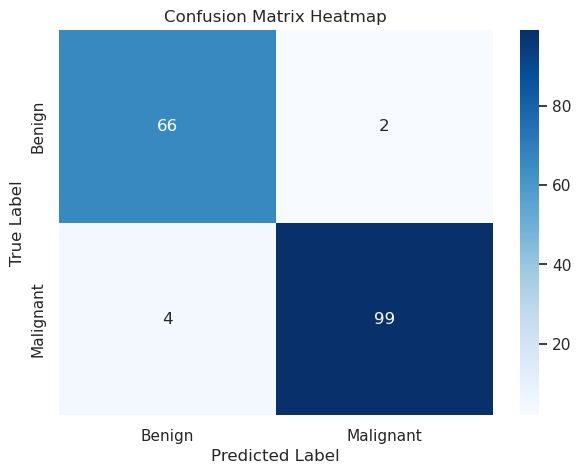

In [34]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'Malignant'], 
            yticklabels=['Benign', 'Malignant'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()